In [21]:
import os
import glob
import random
import gc
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import data
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import requests
import zipfile
import io

In [22]:
!git clone https://github.com/Ehsanacc/iMIAP.git

fatal: destination path 'iMIAP' already exists and is not an empty directory.


In [23]:
# Define paths
ZIP_PATH = '/kaggle/working/iMIAP/Assignment 2/train_data/train_data.zip'
EXTRACT_DIR = '/kaggle/working/iMIAP/Assignment 2/train_data/'

# Ensure the extraction directory exists
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Unzip the file
try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print(f"Successfully extracted {ZIP_PATH} to {EXTRACT_DIR}")
except zipfile.BadZipFile:
    print(f"Error: {ZIP_PATH} is not a valid zip file.")
except FileNotFoundError:
    print(f"Error: {ZIP_PATH} not found.")
except Exception as e:
    print(f"Error during extraction: {str(e)}")

# Update DATA_ROOT to point to the unzipped directory
DATA_ROOT = EXTRACT_DIR

# Verify the extracted directory contains patient folders
patient_dirs = [os.path.join(DATA_ROOT, d) for d in os.listdir(DATA_ROOT) 
                if os.path.isdir(os.path.join(DATA_ROOT, d))]
if patient_dirs:
    print(f"Found {len(patient_dirs)} patient directories in {DATA_ROOT}")
else:
    print(f"Warning: No patient directories found in {EXTRACT_DIR}")

Successfully extracted /kaggle/working/iMIAP/Assignment 2/train_data/train_data.zip to /kaggle/working/iMIAP/Assignment 2/train_data/
Found 354 patient directories in /kaggle/working/iMIAP/Assignment 2/train_data/


Patients: 354  |  Samples: 1416

Batches → train: 283 | val: 71


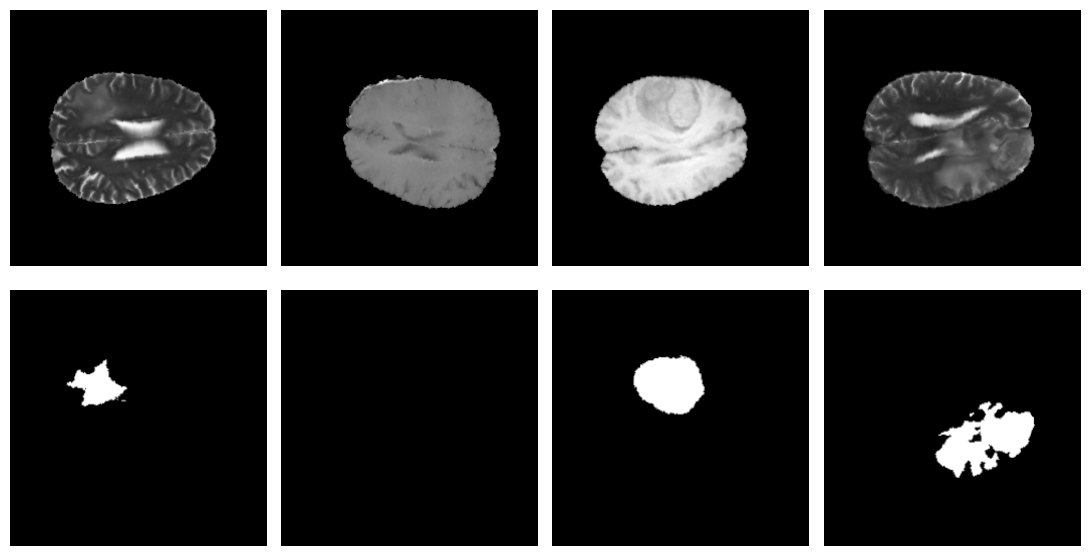

In [24]:
# ---------------------- configuration constants ---------------------
DATA_ROOT   = '/kaggle/working/iMIAP/Assignment 2/train_data/'
MODALITIES  = ('flair', 't1', 't1ce', 't2')
IMG_SIZE    = (256, 256)
BATCH_SIZE  = 8
VAL_SPLIT   = 0.20
SEED        = 67
# --------------------------------------------------------------------

# ------------------------ helper functions --------------------------
def get_patient_dirs(root: str):
    """Return list of patient folders that contain a segmentation file."""
    patients = [os.path.join(root, d) for d in os.listdir(root)
                if os.path.isdir(os.path.join(root, d))]
    return [p for p in patients if glob.glob(os.path.join(p, '*seg.nii*'))]

def collect_samples(patients, modalities=MODALITIES):
    """Return list of (patient_dir, modality) tuples where the image exists."""
    samples = []
    for p in patients:
        for m in modalities:
            if glob.glob(os.path.join(p, f'*{m}.nii*')):
                samples.append((p, m))
    return samples

def slice_from_nifti(path, z):
    """
    Memory-mapped read of axial slice z from a .nii(.gz) file.
    Returns float32 numpy array.
    """
    proxy = nib.load(path).dataobj  # mem-mapped proxy, not full volume
    slice2d = np.asanyarray(proxy[:, :, z])
    return slice2d

def get_transforms(train=True):
    common = [T.Resize(IMG_SIZE)]
    aug    = [T.RandomHorizontalFlip(), T.RandomVerticalFlip(), T.RandomRotation(10)]
    return T.Compose(common + (aug if train else []))

def visualize_batch(loader):
    images, masks = next(iter(loader))
    with torch.no_grad():
        fig, ax = plt.subplots(2, 4, figsize=(11, 6))
        for i in range(4):
            ax[0, i].imshow(images[i, 0].cpu(), cmap='gray'); ax[0, i].axis('off')
            ax[1, i].imshow(masks[i, 0].cpu(),  cmap='gray'); ax[1, i].axis('off')
        plt.tight_layout(); plt.show()
# --------------------------------------------------------------------

# ----------------------------- Dataset ------------------------------
class BraTSDataset(Dataset):
    """
    Yields (1,H,W) image & binary mask tensors in [0,1].
    Uses *lazy* mem-mapped slice loading for minimal RAM usage.
    """
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        patient_dir, modality = self.samples[idx]
        img_path = glob.glob(os.path.join(patient_dir, f'*{modality}.nii*'))[0]
        seg_path = glob.glob(os.path.join(patient_dir, '*seg.nii*'))[0]

        # centre-slice index (header-only read – cheap)
        z = nib.load(img_path).shape[-1] // 2

        # load the two axial slices (still mem-mapped)
        img  = slice_from_nifti(img_path, z)
        mask = slice_from_nifti(seg_path, z)
        mask = (mask > 0).astype(np.float32)

        # ---------- robust [0,1] normalisation (NumPy ≥2.0 safe) ----------
        img_min   = img.min()
        img_range = img.max() - img_min
        if img_range > 0:
            img = (img - img_min) / (img_range + 1e-8)
        else:                      # constant slice: just zeros
            img = np.zeros_like(img, dtype=np.float32)
        # -----------------------------------------------------------------

        # to torch (C,H,W)
        img  = torch.from_numpy(img).unsqueeze(0).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        # identical transform for both tensors
        if self.transform:
            seed = random.randint(0, 2**32 - 1)
            torch.manual_seed(seed); img  = self.transform(img)
            torch.manual_seed(seed); mask = self.transform(mask)

        return img, mask
# --------------------------------------------------------------------

# ========================== build pipeline ===========================
def build_dataloaders():
    # 1. gather samples
    patients = get_patient_dirs(DATA_ROOT)
    samples  = collect_samples(patients)
    print(f'Patients: {len(patients)}  |  Samples: {len(samples)}')

    # 2. split
    train_s, val_s = train_test_split(samples,
                                      test_size=VAL_SPLIT,
                                      random_state=SEED,
                                      shuffle=True)
    # 3. datasets
    train_set = BraTSDataset(train_s, get_transforms(train=True))
    val_set   = BraTSDataset(val_s,   get_transforms(train=False))

    # 4. dataloaders
    dl_kwargs = dict(batch_size=BATCH_SIZE,
                     num_workers=2,
                     pin_memory=True)
    train_dl = DataLoader(train_set, shuffle=True,  **dl_kwargs)
    val_dl   = DataLoader(val_set,   shuffle=False, **dl_kwargs)

    # free temporary lists
    del patients, samples, train_s, val_s
    gc.collect()

    return train_dl, val_dl
# --------------------------------------------------------------------

# ======================= run & quick sanity-check ====================
train_loader, val_loader = build_dataloaders()
print(f'\nBatches → train: {len(train_loader)} | val: {len(val_loader)}')

visualize_batch(train_loader)

In [25]:
##########################################################
# Compute Atrous/Dilated Convolution
##########################################################


class Atrous_Convolution(nn.Module):
    def __init__(
            self, input_channels, kernel_size, pad, dilation_rate,
            output_channels=256):
        super(Atrous_Convolution, self).__init__()
        # Use Conv2d + BN + ReLU like typical ASPP branch
        self.atrous_conv_layer = nn.Sequential(
            nn.Conv2d(in_channels=input_channels,
                      out_channels=output_channels,
                      kernel_size=kernel_size,
                      padding=pad,
                      dilation=dilation_rate,
                      bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.atrous_conv_layer(x)
        return x

In [26]:
# Encoder of DeepLabv3+
class ASSP(nn.Module):

    def __init__(self, in_channles, out_channles):
        """Atrous Spatial Pyramid pooling layer
        Args:
            in_channles (int): No of input channel for Atrous_Convolution.
            out_channles (int): No of output channel for Atrous_Convolution.
        """
        super(ASSP, self).__init__()

        # normalize parameter names
        in_channels = in_channles
        out_channels = out_channles

        self.conv_1x1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

        self.conv_6x6 = Atrous_Convolution(in_channels, kernel_size=3, pad=6, dilation_rate=6, output_channels=out_channels)

        self.conv_12x12 = Atrous_Convolution(in_channels, kernel_size=3, pad=12, dilation_rate=12, output_channels=out_channels)

        self.conv_18x18 = Atrous_Convolution(in_channels, kernel_size=3, pad=18, dilation_rate=18, output_channels=out_channels)

        self.image_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global average pooling
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

        self.final_conv = nn.Sequential(
            nn.Conv2d(out_channels * 5, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Dropout(0.1) # Dropout for regularization, as often used
        )
        
    def forward(self, x):
        # Get feature map dimensions
        h, w = x.shape[2], x.shape[3]

        # Apply each branch
        out_1x1 = self.conv_1x1(x)
        out_atrous_6 = self.conv_6x6(x)
        out_atrous_12 = self.conv_12x12(x)
        out_atrous_18 = self.conv_18x18(x)
        
        # Image pooling branch needs to be resized back to original feature map size
        out_image_pool = self.image_pool(x)
        out_image_pool = F.interpolate(out_image_pool, size=(h, w), mode='bilinear', align_corners=True)

        # Concatenate all outputs along the channel dimension
        concatenated_features = torch.cat([
            out_1x1, 
            out_atrous_6, 
            out_atrous_12, 
            out_atrous_18, 
            out_image_pool
        ], dim=1) # Concatenate along the channel dimension (dim=1)

        # Apply final 1x1 convolution
        output = self.final_conv(concatenated_features)
        
        return output

In [27]:
class ResNet_50(nn.Module):
    def __init__(self, output_layer=None):
        super(ResNet_50, self).__init__()
        self.pretrained = torchvision.models.resnet50(pretrained=True)
        self.output_layer = output_layer

        self.layers = list(self.pretrained._modules.keys())
        self.layer_count = 0
        for l in self.layers:
            if l != self.output_layer:
                self.layer_count += 1
            else:
                break

        for _ in range(len(self.layers) - self.layer_count - 1):
            self.pretrained._modules.pop(self.layers[-1])
            self.layers.pop()

        self.net = nn.Sequential(*self.pretrained._modules.values())

        for param in self.net.parameters():
            param.requires_grad = False

    def forward(self, x):
        # FIX: Repeat grayscale channel to RGB
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        return self.net(x)


In [28]:
##########################################################
# Compute Deeplabv3Plus model
##########################################################


class Deeplabv3Plus(nn.Module):
    def __init__(self, num_classes):

        super(Deeplabv3Plus, self).__init__()

        self.backbone = ResNet_50(output_layer='layer3')

        self.low_level_features = ResNet_50(output_layer='layer1')

        self.assp = ASSP(in_channles=1024, out_channles=256)

        self.conv1x1 = Atrous_Convolution(
            input_channels=256, output_channels=48, kernel_size=1,
            dilation_rate=1, pad=0)

        self.conv_3x3 = nn.Sequential(
            nn.Conv2d(304, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.classifer = nn.Conv2d(256, num_classes, 1)

    def forward(self, x):

        x_backbone = self.backbone(x)
        x_low_level = self.low_level_features(x)
        x_assp = self.assp(x_backbone)
        x_assp_upsampled = F.interpolate(
            x_assp, scale_factor=(4, 4),
            mode='bilinear', align_corners=True)
        x_conv1x1 = self.conv1x1(x_low_level)
        x_cat = torch.cat([x_conv1x1, x_assp_upsampled], dim=1)
        x_3x3 = self.conv_3x3(x_cat)
        x_3x3_upscaled = F.interpolate(
            x_3x3, scale_factor=(4, 4),
            mode='bilinear', align_corners=True)
        x_out = self.classifer(x_3x3_upscaled)
        return x_out

In [29]:
##########################################################
# Complete DiceBCELoss and IOU
##########################################################


class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, inputs, targets, smooth=1):
        """
        inputs: logits (B,1,H,W)
        targets: binary mask (B,1,H,W)
        """
        # BCE on logits
        bce_loss = self.bce(inputs, targets)

        # Sigmoid to get probabilities
        probs = torch.sigmoid(inputs)
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)

        intersection = (probs_flat * targets_flat).sum(1)
        total = probs_flat.sum(1) + targets_flat.sum(1)
        dice_score = (2 * intersection + smooth) / (total + smooth)
        dice_loss = 1 - dice_score.mean()

        Dice_BCE = bce_loss + dice_loss
        return Dice_BCE


class IOU(nn.Module):

    def __init__(self, weight=None, size_average=True):
        super(IOU, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        """
        inputs: logits (B,1,H,W)
        targets: binary mask (B,1,H,W)
        returns mean IoU over batch
        """
        probs = torch.sigmoid(inputs)
        preds = (probs > 0.5).float()

        preds_flat = preds.view(preds.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)

        intersection = (preds_flat * targets_flat).sum(1)
        union = preds_flat.sum(1) + targets_flat.sum(1) - intersection

        iou = (intersection + smooth) / (union + smooth)
        return iou.mean().item()

Train the model

/tmp/ipykernel_35/2636778811.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_amp else None


Epoch: 1/100


  0%|          | 0/283 [00:00<?, ?it/s]/tmp/ipykernel_35/2636778811.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 283/283 [00:16<00:00, 17.52it/s, loss=0.751, dice=0.335, iou=0.381]     


Epoch: 1/100, Training loss: 0.999, Training IoU: 0.3297
Dice score: 0.29749851015357065
Epoch: 2/100


100%|██████████| 283/283 [00:16<00:00, 17.67it/s, loss=0.844, dice=0.243, iou=0.232]    


...

Epoch: 98/100, Training loss: 0.23, Training IoU: 0.7427
Dice score: 0.5744693948769234
Epoch: 99/100


100%|██████████| 283/283 [00:16<00:00, 17.50it/s, loss=0.504, dice=0.56, iou=0.456]  


Epoch: 99/100, Training loss: 0.239, Training IoU: 0.7321
Dice score: 0.5611926378078864
Epoch: 100/100


100%|██████████| 283/283 [00:16<00:00, 17.46it/s, loss=0.124, dice=0.661, iou=0.852] 


Epoch: 100/100, Training loss: 0.232, Training IoU: 0.741
Dice score: 0.5691222894779393


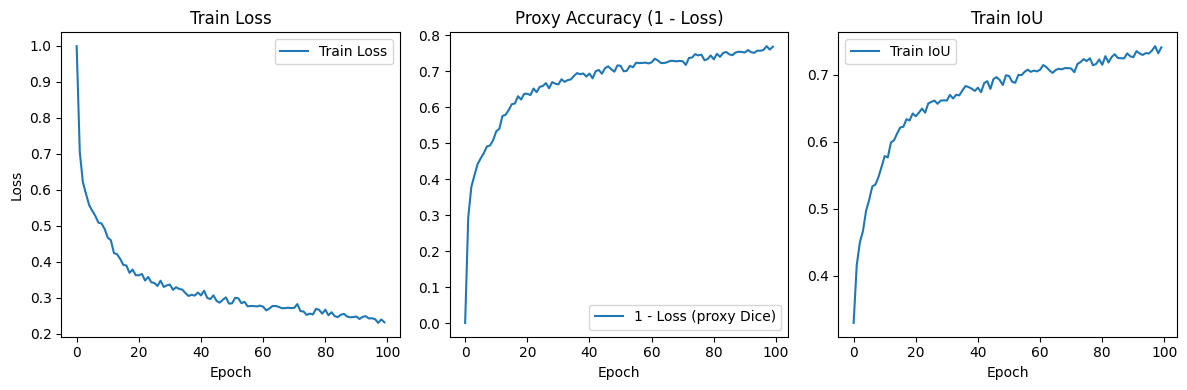

In [32]:
LEARNING_RATE = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 100
NUM_WORKERS = 4
PIN_MEMORY = True
LOAD_MODEL = False

model = Deeplabv3Plus(num_classes=1).to(DEVICE)
loss_fn = DiceBCELoss()
iou_fn = IOU()
# scaler only meaningful on CUDA
use_amp = DEVICE == "cuda"
scaler = torch.cuda.amp.GradScaler() if use_amp else None
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr = LEARNING_RATE)

train_iou = []
train_loss = []

def save_checkpoint(state, filename='checkpoint.pth.tar'):
    torch.save(state, filename)

def compute_dice_from_probs(probs, targets, smooth=1e-6):
    probs_flat = probs.view(probs.size(0), -1)
    targets_flat = targets.view(targets.size(0), -1)
    intersection = (probs_flat * targets_flat).sum(1)
    total = probs_flat.sum(1) + targets_flat.sum(1)
    dice_score = (2 * intersection + smooth) / (total + smooth)
    return dice_score.mean().item()

for epoch in range(NUM_EPOCHS):
    print(f"Epoch: {epoch+1}/{NUM_EPOCHS}")

    iterations = 0
    iter_loss = 0.0
    iter_iou = 0.0

    batch_loop = tqdm(train_loader)
    model.train()
    for batch_idx,(data,targets) in enumerate(batch_loop):
        # move to device
        data = data.to(DEVICE, dtype=torch.float)
        targets = targets.to(DEVICE, dtype=torch.float)

        optimizer.zero_grad()

        if use_amp:
            with torch.cuda.amp.autocast():
                outputs = model(data)  # logits
                loss = loss_fn(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(data)
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()

        # metrics
        with torch.no_grad():
            probs = torch.sigmoid(outputs)
            batch_dice = compute_dice_from_probs(probs, targets)
            batch_iou = IOU()(outputs.detach(), targets.detach())

        iter_loss += loss.item()
        iter_iou += batch_iou
        iterations += 1

        batch_loop.set_postfix({'loss': loss.item(), 'dice': batch_dice, 'iou': batch_iou})

    # epoch aggregates
    avg_loss = iter_loss / max(1, iterations)
    avg_iou = iter_iou / max(1, iterations)
    train_loss.append(avg_loss)
    train_iou.append(avg_iou)

    print(f"Epoch: {epoch+1}/{NUM_EPOCHS}, Training loss: {round(train_loss[-1] , 3)}, Training IoU: {round(train_iou[-1], 4)}")

    checkpoint = {
        "state_dict" : model.state_dict(),
        "optimizer" : optimizer.state_dict()
    }
    save_checkpoint(checkpoint)

    # validation
    dice_score = 0.0
    model.eval()

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(DEVICE, dtype=torch.float)
            y = y.to(DEVICE, dtype=torch.float)

            # forward
            outputs = model(x)
            probs = torch.sigmoid(outputs)

            # compute dice per batch (average)
            batch_dice = compute_dice_from_probs(probs, y)
            dice_score += batch_dice

    val_dice = dice_score / max(1, len(val_loader))
    print(f"Dice score: {val_dice}")

# After training, plot loss, Dice (as proxy accuracy), and IoU
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(train_loss, label='Train Loss')
plt.title('Train Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.subplot(1,3,2)
plt.plot([1 - l for l in train_loss], label='1 - Loss (proxy Dice)')
plt.title('Proxy Accuracy (1 - Loss)')
plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,3,3)
plt.plot(train_iou, label='Train IoU')
plt.title('Train IoU')
plt.xlabel('Epoch'); plt.legend()

plt.tight_layout()
plt.show()